# PHOENIX Synthetic Spectra Grid Preparation

AST402 Mid-Term Project

This notebook prepares the PHOENIX-ACES high-resolution synthetic stellar spectra grid.

Parameter grid:

- Effective Temperature (Teff):
  5000 K to 7000 K
  step = 250 K

- Surface gravity (log g):
  3.5 to 5.0 dex
  step = 0.5

- Metallicity ([Fe/H]):
  -0.5, 0.0, +0.5 dex

Total spectra:

9 × 4 × 3 = 108 FITS files

## Step 1 — Import Required Libraries

We use:

- pathlib for directory handling
- numpy for parameter grids
- urllib for downloading files

In [20]:
import os
import numpy as np
from astropy.io import fits
import urllib.request
from itertools import product
from pathlib import Path
import numpy as np
import urllib.request

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Create PHOENIX Data Folders

The project keeps:

data/
 └── PHOENIX/
      ├── raw/
      └── interpolated/

raw:
Original downloaded PHOENIX spectra

interpolated:
New spectra created by interpolation

In [21]:
base_dir = Path("../data/PHOENIX")

raw_dir = base_dir / "raw"
interp_dir = base_dir / "interpolated"


raw_dir.mkdir(
    parents=True,
    exist_ok=True
)

interp_dir.mkdir(
    parents=True,
    exist_ok=True)


print(list(base_dir.iterdir()))

[WindowsPath('../data/PHOENIX/interpolated'), WindowsPath('../data/PHOENIX/processed'), WindowsPath('../data/PHOENIX/raw')]


## Step 3 — Define Stellar Parameter Grid

Parameters are taken directly from Question 3(a).

Teff:
5000–7000 K

log g:
3.5–5.0

[Fe/H]:
-0.5, 0.0, +0.5

In [22]:
Teff_values = np.arange(
    5000,
    7001,
    250
)


logg_values = np.arange(
    3.5,
    5.01,
    0.5
)


FeH_values = [
    -0.5,
    0.0,
    0.5
]


print("Teff values:", Teff_values)
print("logg values:", logg_values)
print("FeH values:", FeH_values)

Teff values: [5000 5250 5500 5750 6000 6250 6500 6750 7000]
logg values: [3.5 4.  4.5 5. ]
FeH values: [-0.5, 0.0, 0.5]


## Step 4 — Calculate Number of PHOENIX Models

The total number of spectra is:

N = N(Teff) × N(log g) × N([Fe/H])

In [23]:
N_Teff = len(Teff_values)
N_logg = len(logg_values)
N_FeH = len(FeH_values)


total_models = (
    N_Teff *
    N_logg *
    N_FeH
)


print("Number of Teff values:", N_Teff)
print("Number of logg values:", N_logg)
print("Number of FeH values:", N_FeH)

print("\nTotal spectra:", total_models)

Number of Teff values: 9
Number of logg values: 4
Number of FeH values: 3

Total spectra: 108


# Raw PHOENIX Download Grid

The PHOENIX archive does not provide all requested interpolated temperatures directly.

We download the bounding temperatures and later interpolate:

5000, 5500, 6000, 6500, 7000 K

In [24]:
raw_Teff_values = [
    5000,
    5500,
    6000,
    6500,
    7000
]


print("Raw Teff values:", raw_Teff_values)
print("Number of raw temperatures:", len(raw_Teff_values))

Raw Teff values: [5000, 5500, 6000, 6500, 7000]
Number of raw temperatures: 5


## Step 5  — Correct PHOENIX Filename Convention

The PHOENIX archive uses:

Metallicity:

[Fe/H] = -0.5

filename:
lte05000-3.50--0.5


[Fe/H] = 0.0

filename:
lte05000-3.50-0.0


[Fe/H] = +0.5

filename:
lte05000-3.50+0.5

In [25]:
def format_feh_filename(feh):

    if feh < 0:
        return f"-{abs(feh):.1f}"

    elif feh == 0:
        return "-0.0"

    else:
        return f"+{feh:.1f}"


def format_feh_folder(feh):

    if feh < 0:
        return "Z-0.5"

    elif feh == 0:
        return "Z-0.0"

    else:
        return "Z+0.5"

## Step 6 — Generate Complete PHOENIX Filename List

In [26]:
filenames = []


for T in Teff_values:

    for g in logg_values:

        for feh in FeH_values:

            filename = (
                f"lte{T:05d}-"
                f"{g:.2f}-"
                f"{format_feh_filename(feh)}"
                ".PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )

            filenames.append(filename)



print("Total filenames generated:", len(filenames))


print("\nFirst 5 files:")

for f in filenames[:5]:
    print(f)

Total filenames generated: 108

First 5 files:
lte05000-3.50--0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-3.50--0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-3.50-+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-4.00--0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-4.00--0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


In [28]:
base_url = (
    "https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/"
    "HiResFITS/PHOENIX-ACES-AGSS-COND-2011/"
)

print(base_url)

https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/


## Step 7 — Generate PHOENIX Download URLs

The archive structure is:

PHOENIX-ACES-AGSS-COND-2011/
    |
    ├── Z-0.5
    ├── Z-0.0
    └── Z+0.5

In [29]:
download_list = []


for T in raw_Teff_values:

    for g in logg_values:

        for feh in FeH_values:


            filename = (
                f"lte{T:05d}-"
                f"{g:.2f}"
                f"{format_feh_filename(feh)}"
                ".PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )


            folder = format_feh_folder(feh)


            url = (
                base_url
                + folder
                + "/"
                + filename
            )


            download_list.append(url)



print("Total URLs:", len(download_list))


for url in download_list[:5]:
    print(url)

Total URLs: 60
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.5/lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z+0.5/lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.5/lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


# Step 8 — Test PHOENIX FITS Download

Before downloading the full grid, we test one representative spectrum.

Selected model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This model will also be used later for spectral processing.

In [ ]:
test_filename = (
    "lte05000-4.50-0.0."
    "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


test_url = (
    base_url
    + "Z-0.0/"
    + test_filename
)


test_path = raw_dir / test_filename


print("URL:")
print(test_url)

print("\nSaving to:")
print(test_path)

URL:
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Saving to:
..\data\PHOENIX\raw\lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


# Step 8.2 — Download Test PHOENIX Spectrum

Download one representative raw PHOENIX model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This verifies that the filename convention and URL construction are correct before downloading the full raw grid.

In [ ]:
if not test_path.exists():

    urllib.request.urlretrieve(
        test_url,
        test_path
    )

    print("Downloaded successfully!")

else:
    print("File already exists")

File already exists


# Step 9 — Download Full Raw PHOENIX Grid

The raw PHOENIX grid contains:

- Teff = 5000, 5500, 6000, 6500, 7000 K
- log g = 3.5, 4.0, 4.5, 5.0
- [Fe/H] = -0.5, 0.0, +0.5

Total:

\[
5 \times 4 \times 3 = 60
\]

files.

Files that already exist will be skipped.

In [ ]:
for url in download_list:

    filename = url.split("/")[-1]

    save_path = raw_dir / filename

    if save_path.exists():

        print("Already exists:")
        print(filename)

    else:

        print("\nDownloading:")
        print(filename)

        try:
            urllib.request.urlretrieve(
                url,
                save_path
            )

            print("SUCCESS")

        except Exception as e:

            print("FAILED")
            print(e)


Downloading:
lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS
Already exists:
lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Downloading:
lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS

Downloading:
lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS
Already exists:
lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Downloading:
lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS

Downloading:
lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS
Already exists:
lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Downloading:
lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS

Downloading:
lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS
Already exists:
lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Downloading:
lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS

Downloading:
lte05500-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCE

# Step 10 — Verify Downloaded Raw PHOENIX Grid

Check that all 60 expected PHOENIX FITS files are present in the raw directory.

In [ ]:
raw_files = list(raw_dir.glob("*.fits"))

print("Number of raw FITS files:", len(raw_files))

Number of raw FITS files: 61


In [ ]:
print(sorted([f.name for f in raw_dir.glob("*.fits")]))

['lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-4.00-0.0.PHOENIX-ACES-AGSS-CO

## Cleanup — Remove Accidental Extra PHOENIX File

A previously downloaded interpolation test file (5750/5700 K) is removed because it is not part of the raw PHOENIX download grid.

In [ ]:
extra_file = raw_dir / "lte05700-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"

if extra_file.exists():
    extra_file.unlink()
    print("Deleted:", extra_file.name)
else:
    print("File not found.")

Deleted: lte05700-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


In [ ]:
print("Number of raw FITS files:", len(list(raw_dir.glob("*.fits"))))

Number of raw FITS files: 60


# Step 11 — Download the PHOENIX Wavelength Grid

All PHOENIX spectra share a common wavelength grid stored in a separate FITS file.

File:

- WAVE_PHOENIX-ACES-AGSS-COND-2011.fits

This file is downloaded once and will be used for all synthetic spectra.

In [ ]:
wave_filename = "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave_url = (
    "https://phoenix.astro.physik.uni-goettingen.de/"
    "data/v2.0/HiResFITS/"
    + wave_filename
)

wave_path = raw_dir / wave_filename

print("URL:")
print(wave_url)

print("\nSaving to:")
print(wave_path)

URL:
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits

Saving to:
..\data\PHOENIX\raw\WAVE_PHOENIX-ACES-AGSS-COND-2011.fits


# Step 11.2 — Download Wavelength Grid

Download the common PHOENIX wavelength array.

If the file already exists, it will not be downloaded again.

In [ ]:
if not wave_path.exists():

    urllib.request.urlretrieve(
        wave_url,
        wave_path
    )

    print("Downloaded successfully!")

else:

    print("File already exists.")

Downloaded successfully!


# Step 12 — Verify the PHOENIX Wavelength Grid

Load the common PHOENIX wavelength array and inspect its size.

All PHOENIX spectra use this wavelength grid.

In [ ]:
wave = fits.getdata(wave_path)

print("Number of wavelength points:", len(wave))
print("First wavelength (Å):", wave[0])
print("Last wavelength (Å):", wave[-1])

Number of wavelength points: 1569128
First wavelength (Å): 500.0
Last wavelength (Å): 54999.75


# Step 13 — Load One PHOENIX Spectrum

Load one representative PHOENIX spectrum together with the common wavelength grid.

Representative model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This verifies that the wavelength array and flux array have identical lengths before further processing.

In [ ]:
model_file = (
    raw_dir /
    "lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

flux = fits.getdata(model_file)

print("Flux points:", len(flux))
print("Wavelength points:", len(wave))

Flux points: 1569128
Wavelength points: 1569128


# Step 14 — Extract the 4700–5000 Å Region

The project focuses on the Hβ spectral region.

Create a wavelength mask selecting:

4700 Å ≤ λ ≤ 5000 Å

Then extract:

- wavelength array
- corresponding flux values

These arrays will be used for convolution, normalization, and comparison with the observed spectrum.

In [ ]:
mask = (wave >= 4700) & (wave <= 5000)

wave_region = wave[mask]
flux_region = flux[mask]

print("Selected wavelength points:", len(wave_region))
print("Region starts at:", wave_region[0], "Å")
print("Region ends at:", wave_region[-1], "Å")

Selected wavelength points: 49999
Region starts at: 4700.004 Å
Region ends at: 5000.0 Å


# Step 15 — Visualize the Extracted Hβ Region

Plot the extracted PHOENIX spectrum between 4700 Å and 5000 Å.

This verifies that the wavelength extraction worked correctly before performing instrumental convolution and continuum normalization.

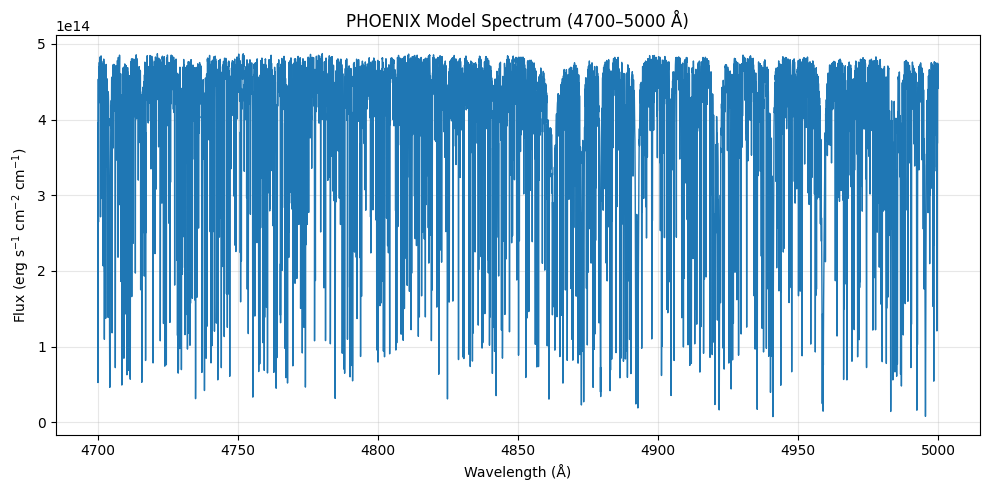

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    wave_region,
    flux_region,
    linewidth=1
)

plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$)")
plt.title("PHOENIX Model Spectrum (4700–5000 Å)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Reload common PHOENIX wavelength array

wave_path = raw_dir / "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave = fits.getdata(wave_path)

print("Wavelength points:", len(wave))
print("First wavelength:", wave[0])
print("Last wavelength:", wave[-1])

Wavelength points: 1569128
First wavelength: 500.0
Last wavelength: 54999.75


# Find the Instrument Information

Inspect the FITS header of the observed spectrum to identify the instrument
and, if available, its resolving power (R).

## Step 16 — Interpolate PHOENIX Models to Teff = 5750 K

The PHOENIX library does not contain a model at 5750 K directly.

The closest available models are:

- Teff = 5500 K
- Teff = 6000 K

For fixed:

- log g = 4.5
- [Fe/H] = 0.0

The 5750 K spectrum is obtained by linear interpolation:

\[
F_{5750}=\frac{F_{5500}+F_{6000}}{2}
\]

In [33]:
# Step 16.1 — Load Bounding PHOENIX Spectra

# Teff = 5500 K model
file_5500 = (
    raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

# Teff = 6000 K model
file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


# Load flux arrays
flux_5500 = fits.getdata(file_5500)
flux_6000 = fits.getdata(file_6000)


# Verify dimensions
print("5500 K flux points:", len(flux_5500))
print("6000 K flux points:", len(flux_6000))
print("Wavelength points:", len(wave))

5500 K flux points: 1569128
6000 K flux points: 1569128
Wavelength points: 1569128


In [34]:
# Step 16.2 — Interpolate to Teff = 5750 K

flux_5750 = (
    flux_5500 +
    flux_6000
) / 2


print("Interpolated 5750 K spectrum created")

print("Flux points:", len(flux_5750))
print("Wavelength points:", len(wave))

Interpolated 5750 K spectrum created
Flux points: 1569128
Wavelength points: 1569128


## Step 16.3 — Extract the Hβ Region from the 5750 K Model

The interpolated PHOENIX spectrum is restricted to the wavelength range:

4700 Å ≤ λ ≤ 5000 Å

This region contains the Hβ absorption line at:

λ₀ = 4861.33 Å

The extracted spectrum will be used for instrumental convolution and continuum normalization.

In [35]:
# Step 16.3 — Extract Hβ region from interpolated spectrum

mask_5750 = (wave >= 4700) & (wave <= 5000)

wave_5750_region = wave[mask_5750]
flux_5750_region = flux_5750[mask_5750]


print("Selected wavelength points:", len(wave_5750_region))
print("Region starts:", wave_5750_region[0], "Å")
print("Region ends:", wave_5750_region[-1], "Å")

Selected wavelength points: 49999
Region starts: 4700.004 Å
Region ends: 5000.0 Å


In [38]:
# Reload required variables after restarting kernel

from pathlib import Path
from astropy.io import fits
import numpy as np


# PHOENIX directories
base_dir = Path("../data/PHOENIX")

raw_dir = base_dir / "raw"


# Reload wavelength grid
wave_path = raw_dir / "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave = fits.getdata(wave_path)


# Reload 5500K and 6000K spectra

file_5500 = (
   raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


flux_5500 = fits.getdata(file_5500)

flux_6000 = fits.getdata(file_6000)


# Recreate interpolated 5750K spectrum

flux_5750 = (
    flux_5500 +
    flux_6000
) / 2


print("Wavelength points:", len(wave))
print("5750K flux points:", len(flux_5750))

Wavelength points: 1569128
5750K flux points: 1569128


In [39]:
from astropy.io import fits
import numpy as np
from pathlib import Path


# PHOENIX files

file_5500 = (
    raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


print(file_5500)
print(file_6000)

..\data\PHOENIX\raw\lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
..\data\PHOENIX\raw\lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


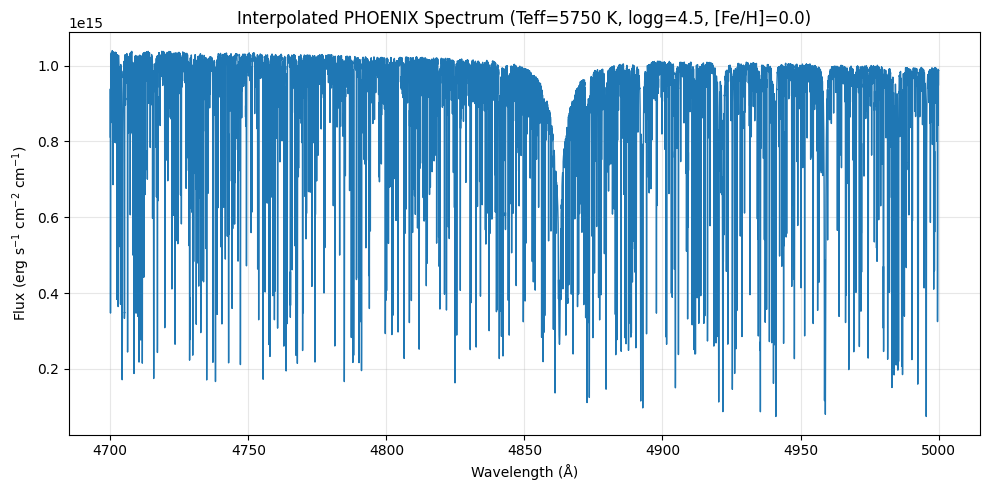

In [40]:
# Step 16.4 — Plot interpolated 5750 K Hβ region

import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    wave_5750_region,
    flux_5750_region,
    linewidth=1
)

plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$)")

plt.title(
    "Interpolated PHOENIX Spectrum "
    "(Teff=5750 K, logg=4.5, [Fe/H]=0.0)"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [41]:
# Find minimum flux near Hβ line

hbeta_mask = (
    (wave_5750_region >= 4840) &
    (wave_5750_region <= 4880)
)

hbeta_wave = wave_5750_region[hbeta_mask]
hbeta_flux = flux_5750_region[hbeta_mask]


min_index = np.argmin(hbeta_flux)

print("Hβ minimum wavelength:")
print(hbeta_wave[min_index], "Å")

print("\nMinimum flux:")
print(hbeta_flux[min_index])

Hβ minimum wavelength:
4872.678 Å

Minimum flux:
111139330000000.0


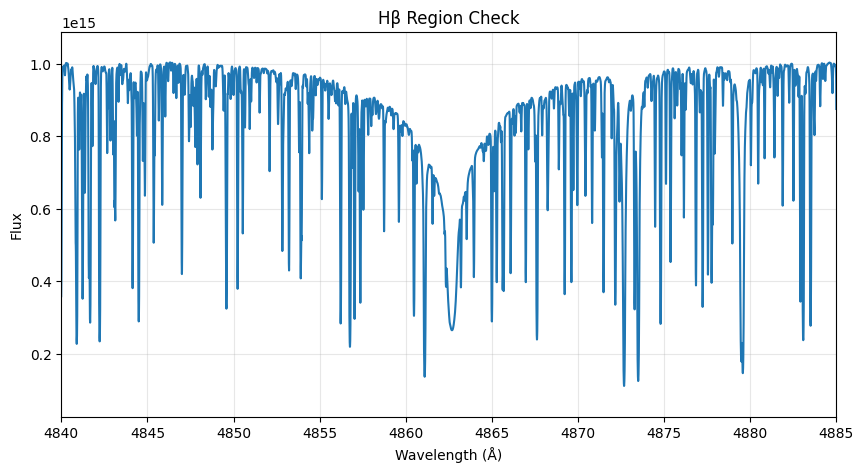

In [42]:
plt.figure(figsize=(10,5))

plt.plot(
    wave_5750_region,
    flux_5750_region
)

plt.xlim(4840,4885)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Hβ Region Check")

plt.grid(alpha=0.3)

plt.show()

In [43]:
# Print wavelength points around expected Hβ

near_hbeta = (
    (wave_5750_region >= 4855) &
    (wave_5750_region <= 4868)
)

print(
    wave_5750_region[near_hbeta][:10]
)

print(
    flux_5750_region[near_hbeta][:10]
)

[4855.002 4855.008 4855.014 4855.02  4855.026 4855.032 4855.038 4855.044
 4855.05  4855.056]
[9.6005995e+14 9.6074741e+14 9.6104591e+14 9.6104014e+14 9.6083894e+14
 9.6053206e+14 9.6017081e+14 9.5976587e+14 9.5928296e+14 9.5862267e+14]


## Step 17 — Instrumental Convolution of PHOENIX Spectrum

The PHOENIX synthetic spectrum has a very high resolving power:

R ≈ 500,000

The observed ELODIE spectrum has:

R = 36788.43

To compare both spectra, the PHOENIX model is convolved with a Gaussian kernel.

The Gaussian width is:

σλ = λ / (2.355 R)

where R is the instrumental resolving power.

In [44]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


# ELODIE resolving power from observed spectrum
R_obs = 36788.43


# Choose central wavelength of Hβ region
lambda_center = 4861.33


# Gaussian sigma in Angstrom
sigma_lambda = lambda_center / (2.355 * R_obs)


# PHOENIX wavelength sampling
delta_lambda = wave_5750_region[1] - wave_5750_region[0]


# Convert sigma from Angstrom to pixels
sigma_pixels = sigma_lambda / delta_lambda


print("Sigma wavelength:", sigma_lambda, "Å")
print("Sigma pixels:", sigma_pixels)

Sigma wavelength: 0.05611163682045048 Å
Sigma pixels: 9.351939469587428


In [45]:
flux_5750_convolved = gaussian_filter1d(
    flux_5750_region,
    sigma_pixels
)


print("Convolution completed")

Convolution completed


## Step 17.1 — Compare Original and Convolved PHOENIX Spectrum

The high-resolution PHOENIX spectrum is convolved with a Gaussian kernel
to match the resolving power of the observed ELODIE spectrum.

The convolution broadens the spectral absorption features while preserving
the overall line shape.

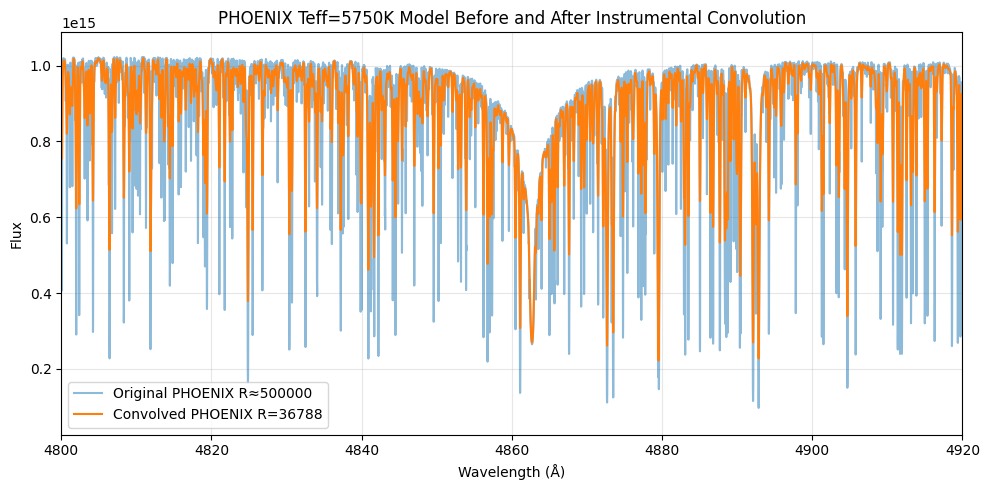

In [47]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.plot(
    wave_5750_region,
    flux_5750_region,
    label="Original PHOENIX R≈500000",
    alpha=0.5
)


plt.plot(
    wave_5750_region,
    flux_5750_convolved,
    label="Convolved PHOENIX R=36788"
)


plt.xlim(4800,4920)


plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")


plt.title(
    "PHOENIX Teff=5750K Model Before and After Instrumental Convolution"
)


plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Step 18 — Continuum Normalization of Convolved PHOENIX Spectrum

The convolved PHOENIX model is normalized using the same pseudo-continuum
windows used for the observed spectrum.

Continuum windows:

- Blue side: 4750–4810 Å
- Red side: 4920–4950 Å

A low-order polynomial is fitted to these regions and used as the
pseudo-continuum.

The normalized spectrum is:

\[
F_{norm}(\lambda)=\frac{F(\lambda)}{F_c(\lambda)}
\]

In [48]:
import numpy as np
import matplotlib.pyplot as plt


# Continuum windows
blue_window = (
    (wave_5750_region >= 4750) &
    (wave_5750_region <= 4810)
)

red_window = (
    (wave_5750_region >= 4920) &
    (wave_5750_region <= 4950)
)


# Combine continuum points
continuum_mask = blue_window | red_window


wave_cont = wave_5750_region[continuum_mask]
flux_cont = flux_5750_convolved[continuum_mask]


print("Continuum points:", len(wave_cont))

Continuum points: 15001


# Step 18.2 — Fit Continuum Polynomial



In [49]:
# Degree 2 polynomial continuum fit

coeff = np.polyfit(
    wave_cont,
    flux_cont,
    deg=2
)


continuum_fit = np.polyval(
    coeff,
    wave_5750_region
)


print("Continuum fitting completed")

Continuum fitting completed


In [50]:
# Step 18.3 — Normalize Spectrum

flux_5750_normalized = (
    flux_5750_convolved /
    continuum_fit
)


print("Normalized spectrum created")

print(
    "Minimum normalized flux:",
    np.min(flux_5750_normalized)
)

Normalized spectrum created
Minimum normalized flux: 0.1931545842419707


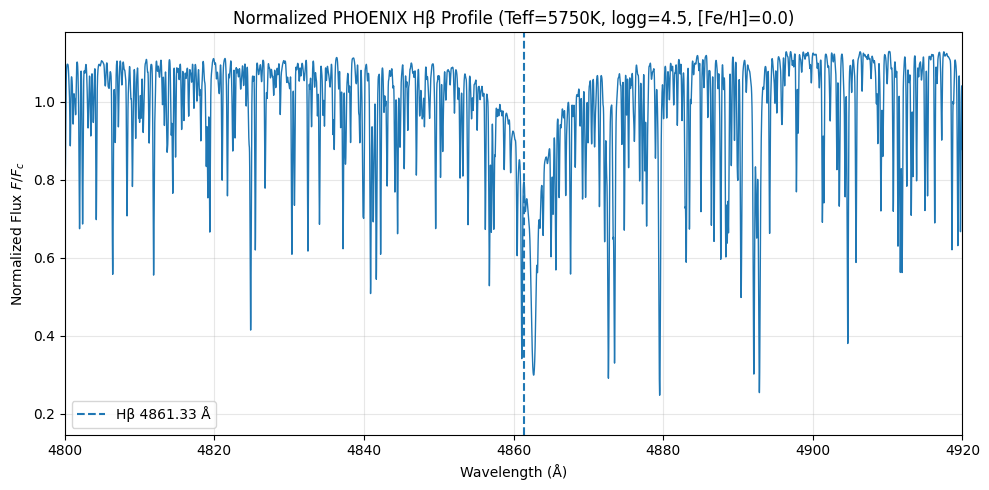

In [51]:
plt.figure(figsize=(10,5))


plt.plot(
    wave_5750_region,
    flux_5750_normalized,
    linewidth=1
)


plt.xlim(4800,4920)


plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Normalized Flux $F/F_c$")


plt.title(
    "Normalized PHOENIX Hβ Profile "
    "(Teff=5750K, logg=4.5, [Fe/H]=0.0)"
)


plt.axvline(
    4861.33,
    linestyle="--",
    label="Hβ 4861.33 Å"
)


plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()